# V1.3 — Nonlinear-rate lumping: the Jensen sub-cell-variance correction

**Tier 1 / Verification Protocol §V1.3.** Targets architecture **Decision #16** and §III.4
*"the nonlinear trap"*. **Depends on** V0.1 (the homogenization cell). The **last Tier-1 gate**
before the Phase-0 tree slice (exit criteria §9: Phase 0 begins once V1.1–V1.3 pass).

> Folder note: `verification_notebooks/phaseN` = **Tier N**. This is Tier 1, *not* architecture "Phase 1".

### The trap, stated precisely
A homogenized cell carries one mean temperature `T̄`. But the reaction rate is the Arrhenius law
`g(T)=exp(−Ta/T)`, which is **convex** over the physical range (`Ta/T ≫ 2`). By Jensen's
inequality `⟨g(T)⟩ ≥ g(T̄)`: **lumping at the mean systematically UNDER-estimates the rate**. A
cell with a 700 °C face and a 60 °C core has a mean temperature whose Arrhenius rate badly
underestimates the face's pyrolysis — and in a coupled burn that error can **silently extinguish
the fire** (a correctness failure masquerading as physics). The architecture's fix: carry the
sub-cell **variance** `σ²_T` and apply the second-order (Jensen) correction
$$ g_\text{corr}(\bar T,\sigma^2) = g(\bar T) + \tfrac12\,g''(\bar T)\,\sigma^2_T,\qquad g''>0 \Rightarrow \text{correction}>0. $$
This is the **second tracked homogenization error** — the *variance* term that joins V0.1's
Voigt–Reuss *responses* term. The 2nd-order truncation itself fails once higher moments dominate;
that breakdown is the wired refine trigger via the dimensionless `ε = ½σ²|g''/g|`.

### Claims (falsifiable)
- **A1 — the hazard.** Mean-only lumping under-estimates the true cell-averaged rate by **>50%**
  in steep cells, for every profile (Jensen sign + magnitude).
- **A2 — the correction works.** Up to a documented steepness (`ε < ε*`), the variance-corrected
  rate is within **<10%** of the fine-scale true rate.
- **B — the refine trigger.** `ε > ε*` catches **100%** of cells where the 2nd-order correction
  exceeds 10% (no false negatives); the strongly non-Gaussian **bimodal** profile breaks earliest.
- **C — spurious extinction (the payoff).** In a coupled mini-burn of a cool-mean / hot-face cell,
  **mean-only lumping spuriously extinguishes** the reaction (fuel consumed ≪ truth) while the
  **variance-corrected** cell and the **fine-scale truth** both sustain it.

### Oracle (independent ground truth)
The **fine-scale integral** of the rate over the resolved sub-cell temperature field,
`true_mean_rate = A·⟨g(T)⟩` (protocol §V1.3 oracle); for the extinction demo, a full-resolution
coupled burn (`run_fine`, every sub-voxel gets its own rate — no homogenization).

### Pre-registered pass criteria (frozen before running)
| # | Metric | Threshold | Failure → outcome |
|---|--------|-----------|-------------------|
| A1 | mean-only under-estimate at the documented steep face | **>50%**, all profiles | — (establishes the hazard) |
| A2 | variance-corrected error for cells with `ε < ε*` | **<10%** of true rate | CONSTRAIN (correct earlier) |
| B | `ε > ε*` vs corrected-error-over-10% | **0 false negatives** (every >10% cell has `ε>ε*`) | CONSTRAIN (lower `ε*`) |
| C | mean-only vs fine fuel consumed (cool-mean/hot-face) | mean-only **<25%** of fine (extinct) **and** corrected **>50%** of fine (sustain) | CONSTRAIN |

**Outcome.** PASS confirms the variance correction recovers nonlinear rates over a documented
validity region, mean-only lumping demonstrably kills a real burn, and `ε` is the wired refine
trigger past the 2nd-order edge. **Standing CONSTRAINT:** carry sub-cell variance for
nonlinear-rate cells; refine when `ε > ε*`.

In [1]:
"""(1) Setup — imports, frozen pre-registered constants, the 3-profile battery."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import fire_operators as fo
import jensen_rate as jr

np.seterr(all="ignore")
np.set_printoptions(precision=4, suppress=True)
P = fo.FireParams()
A, TA = P.A_py, P.Ta_py            # pyrolysis: the steep Arrhenius law (the architecture's example)

# ---- PRE-REGISTERED constants (frozen after calibration) ----
N_FIELD   = 24                     # sub-cell resolution of the temperature field
CORE      = 600.0                  # cold-core temperature [K] (held; the active pyrolysis base)
FACES     = [630.0, 660.0, 720.0, 850.0, 1050.0]   # swept hot-face temperatures -> steepness ΔT
STEEP_FACE = 1050.0                # the documented "steep" face for A1 (>50% underestimate)
EPS_STAR  = 0.5                    # criterion B: the variance-error refine threshold ε*
UNDER_TOL = 0.50                   # A1: mean-only must under-estimate by > this in steep cells
CORR_TOL  = 0.10                   # A2/B: 2nd-order correction validity bound (10%)
PROFILES  = jr.PROFILES            # ramp / boundary_layer / bimodal

# extinction-demo config (cool mean, hot face -> mean-only dies, variance keeps it alive)
EX = dict(n=6, T_lo=350.0, T_hi=720.0, hot_frac=0.25, dt=0.02, nsteps=50, m_s0=3.0)
EX_EXTINCT = 0.25                  # mean-only fuel < this * fine  => spuriously extinguished
EX_SUSTAIN = 0.50                  # corrected fuel > this * fine  => sustained

print(f"profiles: {list(PROFILES)}   core={CORE:.0f}K  faces={FACES}")
print(f"ε*={EPS_STAR}  corrected-tol={CORR_TOL:.0%}  under-tol={UNDER_TOL:.0%}")
print("Arrhenius convexity check g''>0 at the base:",
      bool(jr.g2(CORE, TA) > 0), f"(g''/g = {jr.g2(CORE,TA)/jr.g(CORE,TA):.2e})")


profiles: ['ramp', 'boundary_layer', 'bimodal']   core=600K  faces=[630.0, 660.0, 720.0, 850.0, 1050.0]
ε*=0.5  corrected-tol=10%  under-tol=50%
Arrhenius convexity check g''>0 at the base: True (g''/g = 5.42e-04)


## (2) Experiments A & B — rate recovery and the refine trigger

For each profile and hot-face temperature: the fine-scale **true** rate `A·⟨g(T)⟩` (oracle), the
**mean-only** lumped rate `A·g(T̄)`, the **variance-corrected** rate, and the variance-error
scalar `ε`. Mean-only under-estimates (Jensen); corrected recovers it until `ε` crosses `ε*`.

In [2]:
"""(2) A/B — sweep profiles × faces; mean-only underestimate, corrected error, ε."""
res = {}     # profile -> dict of arrays over FACES
for name, fn in PROFILES.items():
    under, corr, eps, dT = [], [], [], []
    for face in FACES:
        f = fn(N_FIELD, CORE, face)
        true = jr.true_mean_rate(f, A, TA)
        mo   = jr.mean_only_rate(f, A, TA)
        co   = jr.variance_corrected_rate(f, A, TA)
        under.append(1.0 - mo / true)
        corr.append(abs(co - true) / true)
        eps.append(jr.variance_error_scalar(float(f.mean()), float(f.var()), TA))
        dT.append(face - CORE)
    res[name] = {k: np.array(v) for k, v in
                 dict(under=under, corr=corr, eps=eps, dT=dT).items()}
    print(f"  {name:14s} ΔT={[int(d) for d in dT]}")
    print(f"      mean-only under-est = {[f'{u:.0%}' for u in under]}")
    print(f"      corrected error     = {[f'{c:.0%}' for c in corr]}   ε={[f'{e:.2f}' for e in eps]}")

iface = FACES.index(STEEP_FACE)
A1_PASS = all(res[p]["under"][iface] > UNDER_TOL for p in res)

# A2: every cell with ε<ε* must have corrected error < 10%
below = [(p, j) for p in res for j in range(len(FACES)) if res[p]["eps"][j] < EPS_STAR]
A2_PASS = all(res[p]["corr"][j] < CORR_TOL for p, j in below)
maxcorr_below = max(res[p]["corr"][j] for p, j in below)

# B: no false negatives — every cell with corrected error >10% must have ε>ε*
over = [(p, j) for p in res for j in range(len(FACES)) if res[p]["corr"][j] > CORR_TOL]
B_PASS = all(res[p]["eps"][j] > EPS_STAR for p, j in over)
mineps_over = min((res[p]["eps"][j] for p, j in over), default=float("inf"))
# which profile trips ε* at the smallest ΔT (breaks earliest)
earliest = min(res, key=lambda p: next((res[p]["dT"][j] for j in range(len(FACES))
                                        if res[p]["eps"][j] > EPS_STAR), 1e9))

print(f"\n  A1 (steep face {STEEP_FACE:.0f}): underest "
      f"{ {p: f'{res[p]['under'][iface]:.0%}' for p in res} }  -> {'PASS' if A1_PASS else 'FAIL'}")
print(f"  A2 (ε<ε*): max corrected err = {maxcorr_below:.1%} (<{CORR_TOL:.0%})  -> {'PASS' if A2_PASS else 'FAIL'}")
print(f"  B  (ε>ε* catches all >10%): min ε over breakdown = {mineps_over:.3f} (>{EPS_STAR})  "
      f"-> {'PASS' if B_PASS else 'FAIL'};  earliest-breaking profile = {earliest}")


  ramp           ΔT=[30, 60, 120, 250, 450]
      mean-only under-est = ['2%', '6%', '18%', '41%', '57%']
      corrected error     = ['0%', '0%', '0%', '3%', '5%']   ε=['0.02', '0.07', '0.22', '0.64', '1.20']
  boundary_layer ΔT=[30, 60, 120, 250, 450]
      mean-only under-est = ['1%', '5%', '20%', '56%', '83%']
      corrected error     = ['0%', '1%', '5%', '27%', '53%']   ε=['0.01', '0.05', '0.18', '0.68', '1.82']
  bimodal        ΔT=[30, 60, 120, 250, 450]
      mean-only under-est = ['5%', '17%', '46%', '81%', '93%']
      corrected error     = ['0%', '3%', '14%', '40%', '59%']   ε=['0.04', '0.16', '0.60', '2.10', '5.02']

  A1 (steep face 1050): underest {'ramp': '57%', 'boundary_layer': '83%', 'bimodal': '93%'}  -> PASS
  A2 (ε<ε*): max corrected err = 5.3% (<10%)  -> PASS
  B  (ε>ε* catches all >10%): min ε over breakdown = 0.597 (>0.5)  -> PASS;  earliest-breaking profile = bimodal


## (3) Experiment C — the spurious-extinction demo (load-bearing payoff)

A single coarse cell with a **cool mean and a hot face** (bimodal): mean-only lumping evaluates
the rate at the cool mean → the reaction stalls → the burn is **silently extinguished**; the
variance correction sees the hot face → the cell keeps reacting, matching the **fine-scale truth**
(every sub-voxel resolved). The figure tracks cumulative fuel consumed.

In [3]:
"""(3) C — coupled mini-burn: fine truth vs corrected vs mean-only (cumulative fuel)."""
fld = jr.bimodal_field(EX["n"], EX["T_lo"], EX["T_hi"], EX["hot_frac"])
Tbar0, var = float(fld.mean()), float(fld.var())
Tt_fi, fuel_fi = jr.run_fine(fld, P, EX["dt"], EX["nsteps"], m_s0=EX["m_s0"])
Tt_mo, fuel_mo = jr.run_lumped(Tbar0, var, P, EX["dt"], EX["nsteps"], corrected=False, m_s0=EX["m_s0"])
Tt_co, fuel_co = jr.run_lumped(Tbar0, var, P, EX["dt"], EX["nsteps"], corrected=True,  m_s0=EX["m_s0"])
ffi, fco, fmo = fuel_fi[-1], fuel_co[-1], fuel_mo[-1]

C_PASS = (fmo < EX_EXTINCT * ffi) and (fco > EX_SUSTAIN * ffi)
print(f"  cool-mean/hot-face bimodal cell  T̄0={Tbar0:.0f}K  σ²={var:.0f}")
print(f"  fuel/cell consumed:  fine={ffi:.3f}   corrected={fco:.3f}   mean-only={fmo:.3f}")
print(f"  mean-only/fine = {fmo/ffi:.1%} (extinct if <{EX_EXTINCT:.0%})   "
      f"corrected/fine = {fco/ffi:.1%} (sustain if >{EX_SUSTAIN:.0%})  -> {'PASS' if C_PASS else 'FAIL'}")


  cool-mean/hot-face bimodal cell  T̄0=473K  σ²=30422
  fuel/cell consumed:  fine=1.000   corrected=0.927   mean-only=0.046
  mean-only/fine = 4.6% (extinct if <25%)   corrected/fine = 92.7% (sustain if >50%)  -> PASS


## (4) Figures

saved figure -> /workspace/nebula/verification_notebooks/phase1/results/V1_3_jensen_variance.png


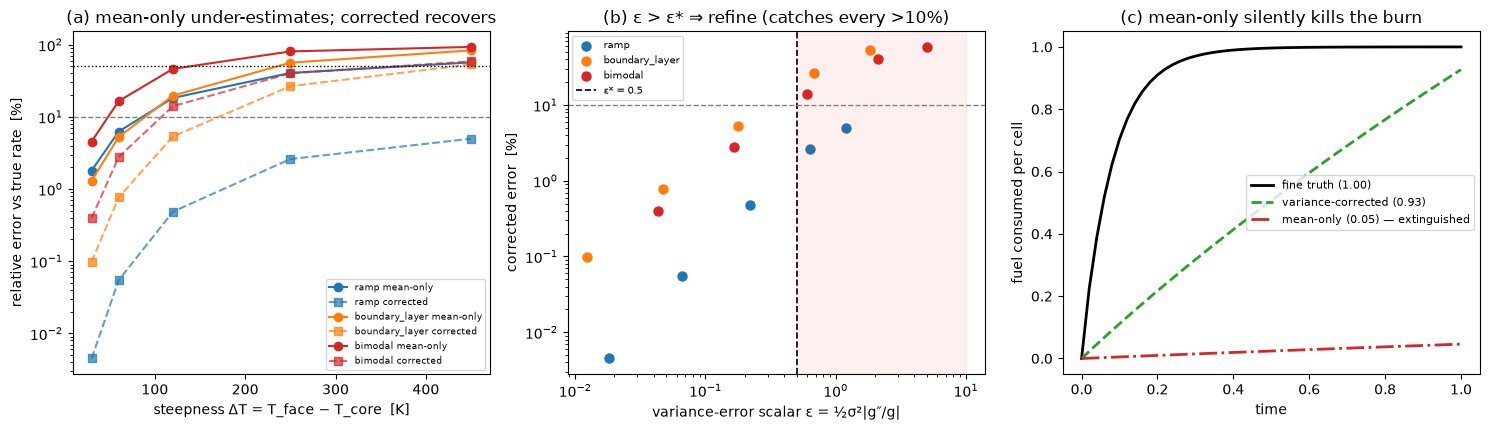

In [4]:
"""(4) Figures: (a) rate error vs steepness; (b) ε refine trigger; (c) extinction demo."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
colors = {"ramp": "tab:blue", "boundary_layer": "tab:orange", "bimodal": "tab:red"}

# (a) mean-only (solid) vs corrected (dashed) error vs ΔT, per profile; 50%/10% lines
for name in res:
    dT = res[name]["dT"]
    ax[0].plot(dT, 100 * res[name]["under"], "o-", color=colors[name], label=f"{name} mean-only")
    ax[0].plot(dT, 100 * res[name]["corr"], "s--", color=colors[name], alpha=0.7,
               label=f"{name} corrected")
ax[0].axhline(100 * UNDER_TOL, ls=":", color="k", lw=1)
ax[0].axhline(100 * CORR_TOL, ls="--", color="gray", lw=1)
ax[0].set_yscale("log"); ax[0].set_xlabel("steepness ΔT = T_face − T_core  [K]")
ax[0].set_ylabel("relative error vs true rate  [%]")
ax[0].set_title("(a) mean-only under-estimates; corrected recovers"); ax[0].legend(fontsize=6.5)

# (b) corrected error vs ε, with the ε* refine threshold (no point >10% sits left of ε*)
for name in res:
    ax[1].scatter(res[name]["eps"], 100 * res[name]["corr"], color=colors[name], label=name, s=42)
ax[1].axvline(EPS_STAR, ls="--", color="k", lw=1.2, label=f"ε* = {EPS_STAR}")
ax[1].axhline(100 * CORR_TOL, ls="--", color="gray", lw=1)
ax[1].axvspan(EPS_STAR, 10.0, alpha=0.06, color="red")   # refine region
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("variance-error scalar ε = ½σ²|g″/g|"); ax[1].set_ylabel("corrected error  [%]")
ax[1].set_title("(b) ε > ε* ⇒ refine (catches every >10%)"); ax[1].legend(fontsize=7)

# (c) extinction demo — cumulative fuel consumed per cell vs time
t = np.arange(len(fuel_fi)) * EX["dt"]
ax[2].plot(t, fuel_fi, "-",  color="k",         lw=2, label=f"fine truth ({ffi:.2f})")
ax[2].plot(t, fuel_co, "--", color="tab:green", lw=2, label=f"variance-corrected ({fco:.2f})")
ax[2].plot(t, fuel_mo, "-.", color="tab:red",   lw=2, label=f"mean-only ({fmo:.2f}) — extinguished")
ax[2].set_xlabel("time"); ax[2].set_ylabel("fuel consumed per cell")
ax[2].set_title("(c) mean-only silently kills the burn"); ax[2].legend(fontsize=8)

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase1" / "results"
outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(outdir / "V1_3_jensen_variance.png", dpi=110)
print(f"saved figure -> {outdir / 'V1_3_jensen_variance.png'}")
plt.show()


In [5]:
"""(5) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:32s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 80)
print("V1.3 — NONLINEAR-RATE LUMPING: THE JENSEN SUB-CELL-VARIANCE CORRECTION — VERDICT")
print("=" * 80)
verdict("A1. mean-only hazard (>50%)", A1_PASS,
        f"mean-only under-estimates the true rate by "
        f"{ {p: f'{res[p]['under'][iface]:.0%}' for p in res} } at the steep face", "—")
verdict("A2. correction valid (ε<ε*)", A2_PASS,
        f"variance-corrected error <= {maxcorr_below:.1%} for every cell with ε<{EPS_STAR} "
        f"(< {CORR_TOL:.0%})", "CONSTRAIN (correct earlier)")
verdict("B. refine trigger (ε>ε*)", B_PASS,
        f"ε>ε* catches 100% of >10% cells (min breakdown ε={mineps_over:.2f}); "
        f"'{earliest}' breaks earliest", "CONSTRAIN (lower ε*)")
verdict("C. spurious extinction", C_PASS,
        f"mean-only burns {fmo/ffi:.0%} of the fine truth (extinguished); "
        f"corrected burns {fco/ffi:.0%} (sustained)", "CONSTRAIN")

ALL_PASS = A1_PASS and A2_PASS and B_PASS and C_PASS
print("=" * 80)
if ALL_PASS:
    print("  V1.3 OVERALL: PASS — the Jensen variance correction recovers nonlinear rates over a")
    print("                documented validity region; mean-only lumping silently extinguishes a")
    print("                real burn; ε is the wired refine trigger past the 2nd-order edge.")
    print("  STANDING CONSTRAINT: carry sub-cell variance for nonlinear-rate cells; refine when")
    print("                ε > ε* (the variance term — companion to the Voigt–Reuss gap).")
    print("  -> Tier-1 Phase-0 gate (V1.1–V1.3) COMPLETE; the Phase-0 tree slice is unblocked.")
else:
    print("  V1.3 OVERALL: FAIL — see outcome class above.")
print("=" * 80)
assert ALL_PASS, "V1.3 did not pass — see verdict above."


V1.3 — NONLINEAR-RATE LUMPING: THE JENSEN SUB-CELL-VARIANCE CORRECTION — VERDICT
  [OK ] A1. mean-only hazard (>50%)      PASS
        mean-only under-estimates the true rate by {'ramp': '57%', 'boundary_layer': '83%', 'bimodal': '93%'} at the steep face
  [OK ] A2. correction valid (ε<ε*)      PASS
        variance-corrected error <= 5.3% for every cell with ε<0.5 (< 10%)
  [OK ] B. refine trigger (ε>ε*)         PASS
        ε>ε* catches 100% of >10% cells (min breakdown ε=0.60); 'bimodal' breaks earliest
  [OK ] C. spurious extinction           PASS
        mean-only burns 5% of the fine truth (extinguished); corrected burns 93% (sustained)
  V1.3 OVERALL: PASS — the Jensen variance correction recovers nonlinear rates over a
                documented validity region; mean-only lumping silently extinguishes a
                real burn; ε is the wired refine trigger past the 2nd-order edge.
  STANDING CONSTRAINT: carry sub-cell variance for nonlinear-rate cells; refine when
          